# Basic axial-flux motor evaluation

Build a parametric axial-flux PM motor, evaluate it at an operating point with
the fast analytical model, and inspect performance, constraints, and geometry.

This is the quickstart example from the project SPEC: a 28-pole (14 pole-pair)
motor with a 160 mm outer diameter, evaluated at 500 rpm / 25 A on a 48 V bus.

In [1]:
from pathlib import Path

from axfluxmdo import AxialFluxMotor, OperatingPoint
from axfluxmdo.models import AnalyticalModel
from axfluxmdo.viz import plot_geometry

OUTPUT_DIR = Path(__file__).parent / "output" if "__file__" in globals() else Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

## Define the motor and operating point

The nine leading parameters are the primary design vector; everything else
(magnet grade, steel, winding layout, cooling) has sensible defaults that can
be overridden per design.

In [2]:
motor = AxialFluxMotor(
    outer_radius=0.08,  # m
    inner_radius=0.025,  # m
    air_gap=0.0008,  # m
    pole_pairs=14,
    phases=3,
    turns_per_phase=24,
    fill_factor=0.45,
    magnet_thickness=0.004,  # m
    back_iron_thickness=0.006,  # m
)

op = OperatingPoint(speed_rpm=500, current_rms=25, dc_bus_voltage=48)

## Evaluate with the analytical model

`evaluate` runs the full Layer-1 chain: magnet load line → air-gap field →
torque and back-EMF (energy-consistent by construction) → copper and core
losses → steady-state winding temperature (with resistance-temperature
coupling) → mass rollup → constraint checks.

In [3]:
result = AnalyticalModel().evaluate(motor, op)
print(result)

AnalyticalResult
  torque:            8.629 N·m
  torque density:    2.364 N·m/kg
  back-EMF (rms):    6.02 V/phase
  elec frequency:    116.7 Hz
  air-gap B:         1.016 T
  shear stress:      8.30 kPa
  current density:   4.04 A/mm²
  copper loss:       20.0 W
  core loss:         0.91 W
  output power:      451.8 W
  efficiency:        0.9557
  winding temp:      49.6 °C
  mass:              3.651 kg
  constraints:
    winding_temp_c: 49.57 <= 140 [OK, margin +64.6%]
    electrical_frequency_hz: 116.7 <= 1000 [OK, margin +88.3%]
    current_density_a_mm2: 4.042 <= 10 [OK, margin +59.6%]
    line_voltage_v: 10.9 <= 33.94 [OK, margin +67.9%]
    core_flux_density_t: 0.6696 <= 1.6 [OK, margin +58.2%]
    magnet_temp_c: 65 <= 80 [OK, margin +18.8%]


## Individual quantities

Every result field is a plain float; `to_dict()` gives a flat record for
DataFrames or optimization drivers.

In [4]:
print(f"torque:          {result.torque_nm:.2f} N·m")
print(f"torque density:  {result.torque_density_nm_kg:.2f} N·m/kg")
print(f"efficiency:      {result.efficiency:.4f}")
print(f"winding temp:    {result.winding_temp_c:.1f} °C")
print(f"feasible:        {result.feasible}")

torque:          8.63 N·m
torque density:  2.36 N·m/kg
efficiency:      0.9557
winding temp:    49.6 °C
feasible:        True


## Geometry

Front view of the magnet disk and an axial cross-section of the single-gap
stack (air gap exaggerated for visibility).

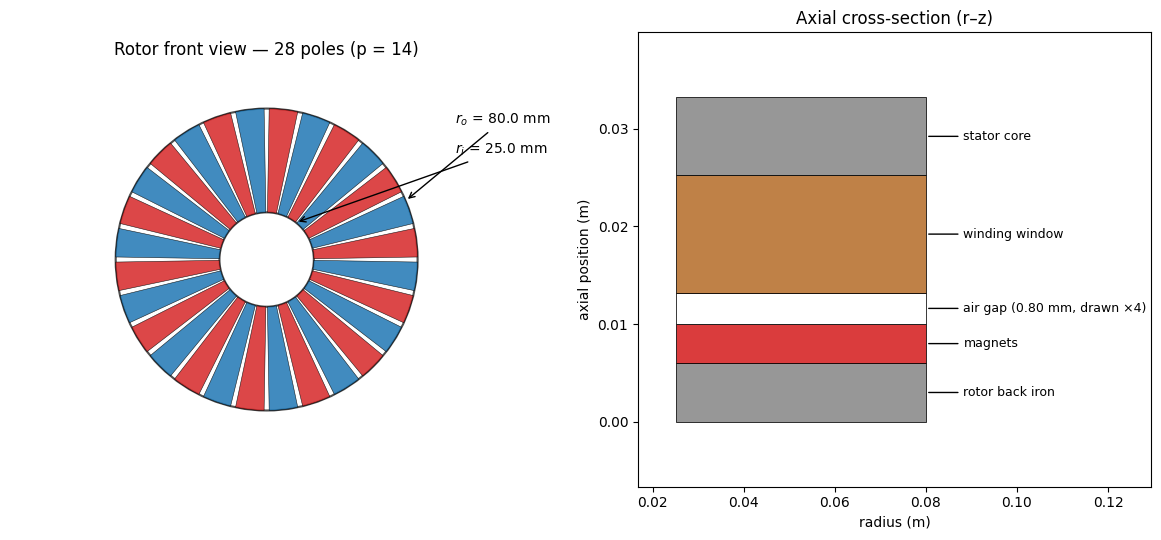

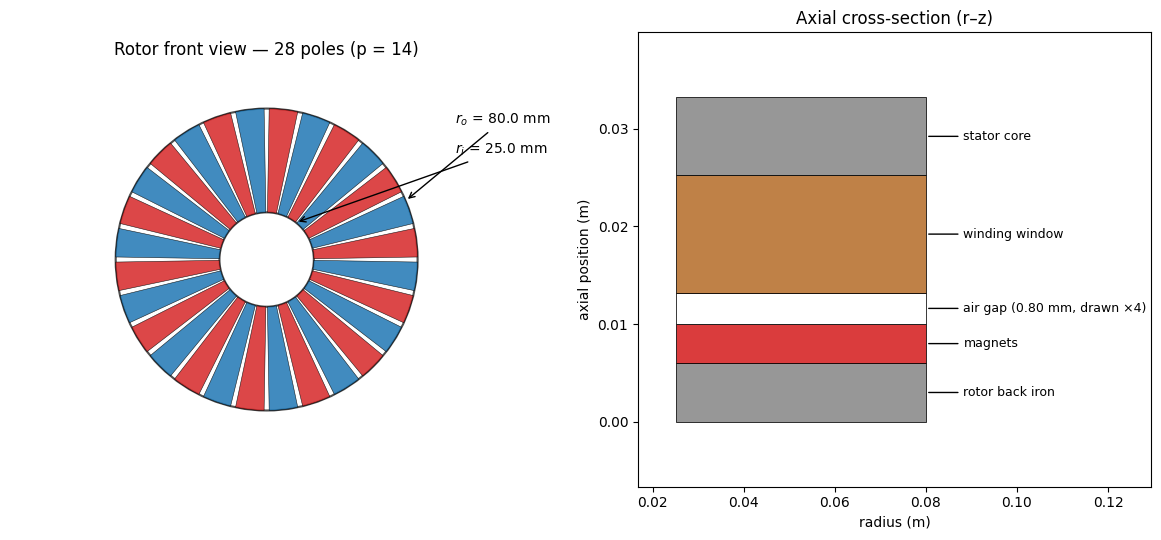

In [5]:
fig = plot_geometry(motor)
fig.savefig(OUTPUT_DIR / "01_geometry.png", dpi=150, bbox_inches="tight")
fig